# Advertising Benchmark

This notebook imports saved advertising runs from `results/advertising`. It is analysis-only and does not run training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    discrete_transport_tv_bound_table,
    load_runs,
    objective_table,
    plot_advertising_diagnostics,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
)

ENV = 'advertising'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 25 saved runs from /home/adonis/Internship/mfc/results/advertising


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. The reward balances customer acquisition against advertising cost.

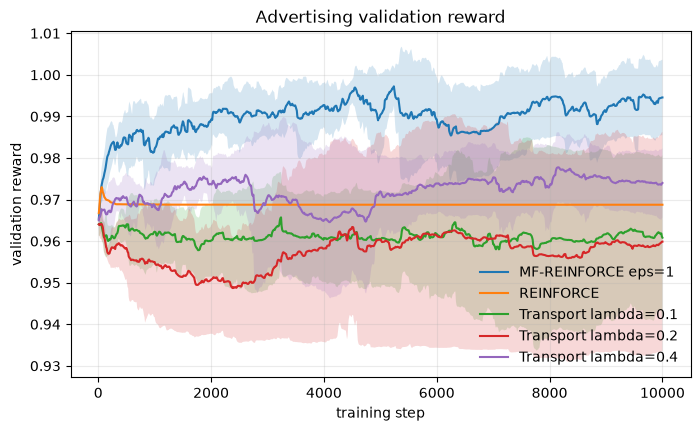

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_validation_rewards(runs, env=ENV, horizon=5, flow='exact', ax=ax)
    ax.set_title('Advertising validation reward')
    plt.show()

## Customer Share and Ad Intensity

For each selected learned policy, this plot shows the customer share and the average probability of displaying an ad over the validation horizon.

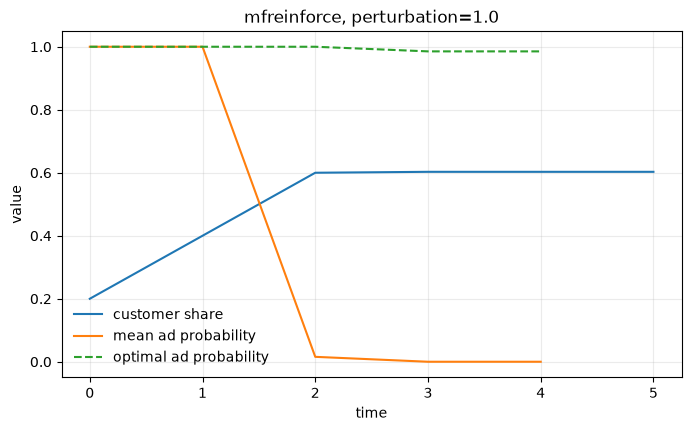

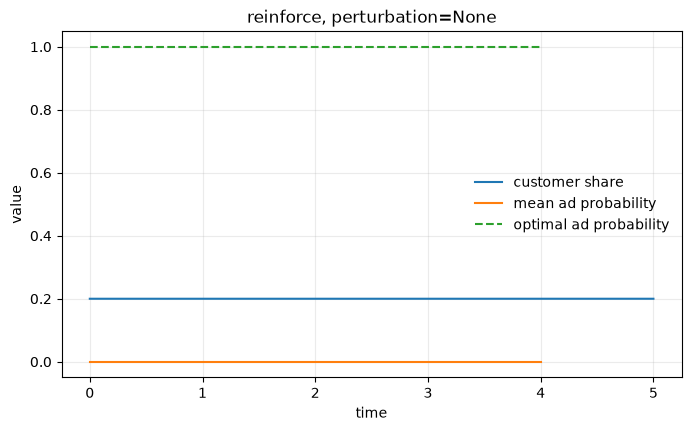

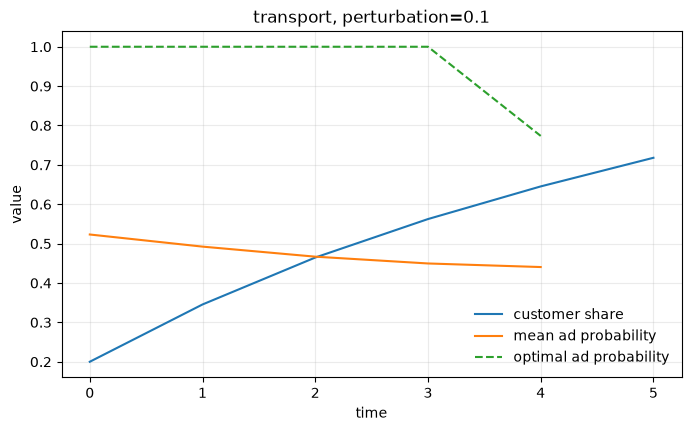

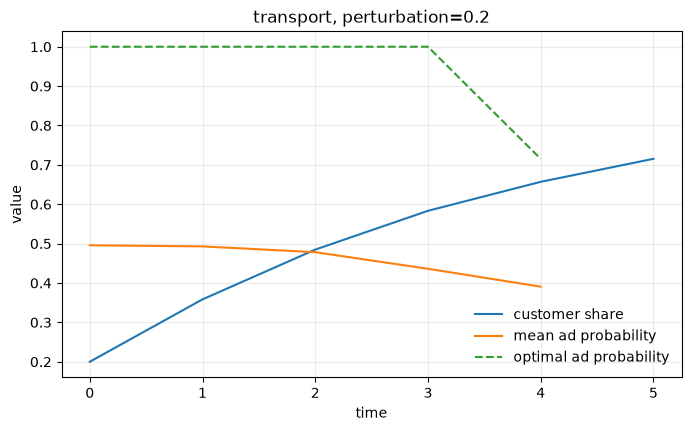

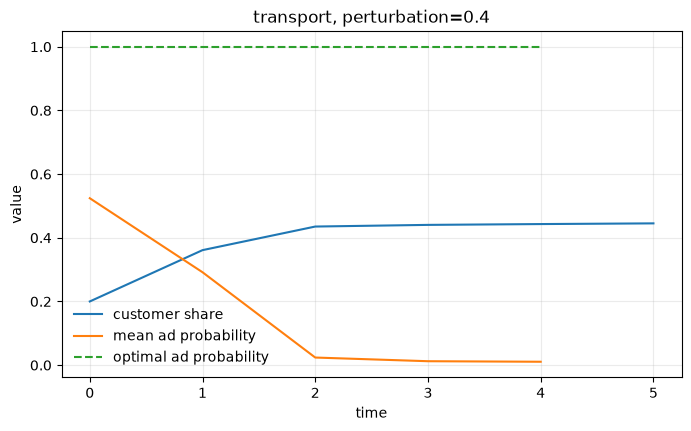

In [3]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_advertising_diagnostics(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## State Distribution Flow

State-probability trajectories for not-customers and customers under the learned policies.

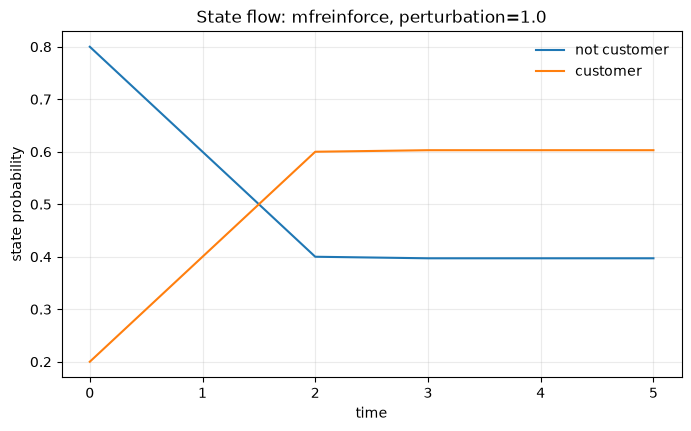

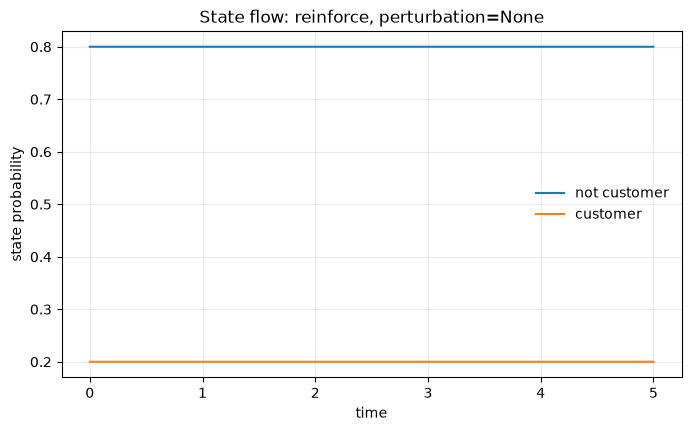

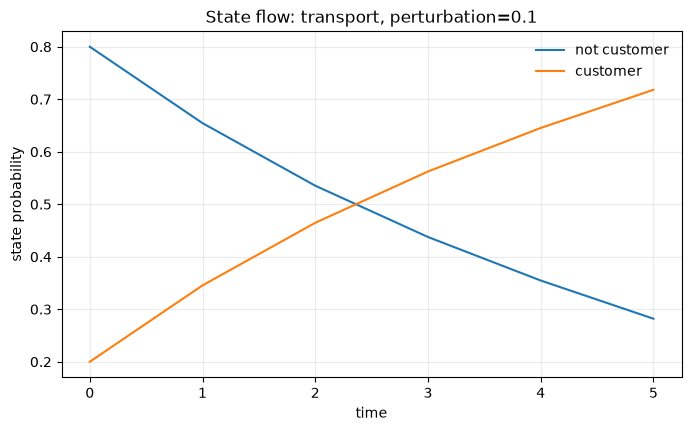

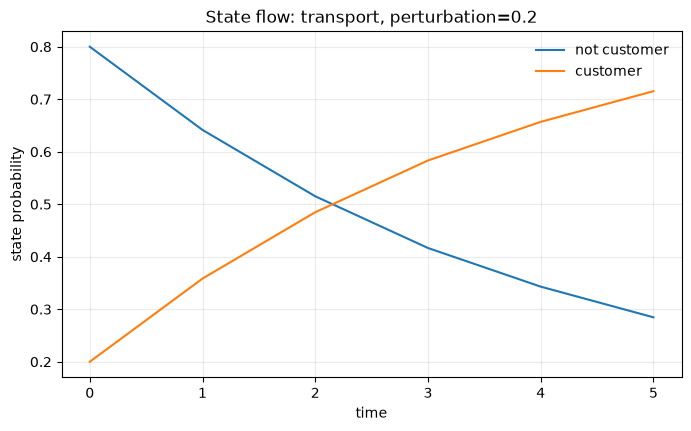

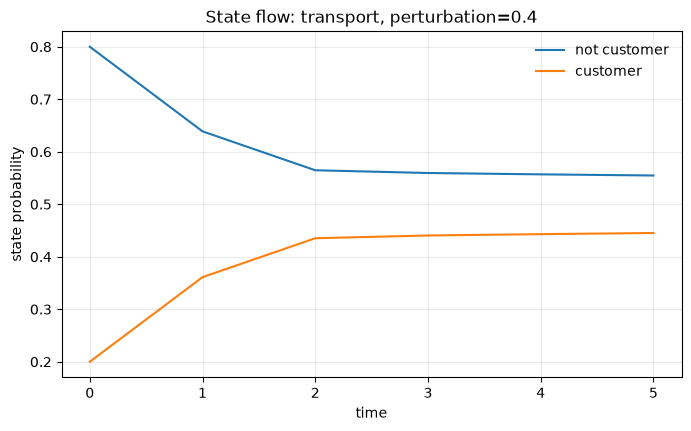

In [4]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"State flow: {meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## Transport Perturbation Bound

For simplex transport, the total-variation distance between the perturbed and unperturbed population laws is bounded by the selected `lambda`.

In [5]:
tv_bounds = discrete_transport_tv_bound_table(runs)
display(tv_bounds if not tv_bounds.empty else pd.DataFrame({'message': ['No transport runs found yet.']}))

,env,label,flow,horizon,seed,lambda,max_tv_upper_bound,satisfies_lambda_bound
0,advertising,Transport lambda=0.1,exact,5,0,0.1,0.080000,True
1,advertising,Transport lambda=0.1,exact,5,1,0.1,0.080743,True
2,advertising,Transport lambda=0.1,exact,5,2,0.1,0.080000,True
3,advertising,Transport lambda=0.1,exact,5,3,0.1,0.098521,True
4,advertising,Transport lambda=0.1,exact,5,4,0.1,0.080000,True
5,advertising,Transport lambda=0.2,exact,5,0,0.2,0.160000,True
6,advertising,Transport lambda=0.2,exact,5,1,0.2,0.160000,True
7,advertising,Transport lambda=0.2,exact,5,2,0.2,0.160000,True
8,advertising,Transport lambda=0.2,exact,5,3,0.2,0.183523,True
9,advertising,Transport lambda=0.2,exact,5,4,0.2,0.160000,True


## Objective and Runtime Tables

Final validation reward, estimated simulator budget, and runtime summaries.

In [6]:
display(objective_table(runs))
display(runtime_table(runs))

,env,label,flow,horizon,seed,validation_reward
0,advertising,MF-REINFORCE eps=1,exact,5,0,0.998890
1,advertising,MF-REINFORCE eps=1,exact,5,1,0.978368
2,advertising,MF-REINFORCE eps=1,exact,5,2,0.998409
3,advertising,MF-REINFORCE eps=1,exact,5,3,0.998976
4,advertising,MF-REINFORCE eps=1,exact,5,4,0.998126
5,advertising,REINFORCE,exact,5,0,0.968750
6,advertising,REINFORCE,exact,5,1,0.968750
7,advertising,REINFORCE,exact,5,2,0.968750
8,advertising,REINFORCE,exact,5,3,0.968750
9,advertising,REINFORCE,exact,5,4,0.968750


,env,algorithm,perturbation,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,advertising,mfreinforce,1.0,5,exact,7.067065,0.164226,306.756741,1.869454,76.509994,0.583483,390.363988,2.492509,0.030676,0.039036,0.076510,1300.0,5
1,advertising,reinforce,NaN,5,exact,7.195278,0.310935,43.787487,1.584063,77.333402,1.780755,128.350119,3.483417,0.004379,0.012835,0.077333,1300.0,5
2,advertising,transport,0.1,5,exact,7.245845,0.212661,232.347626,3.082153,77.334715,1.045666,316.959377,4.231340,0.023235,0.031696,0.077335,1300.0,5
3,advertising,transport,0.2,5,exact,7.464195,1.223696,229.368047,1.180672,76.258255,0.456371,313.120960,1.835502,0.022937,0.031312,0.076258,1300.0,5
4,advertising,transport,0.4,5,exact,7.067348,0.179933,229.761154,1.641157,76.794401,0.239363,313.653404,1.871671,0.022976,0.031365,0.076794,1300.0,5
